# 01 — The Black–Scholes–Merton Model

This notebook derives the **Black–Scholes–Merton (BSM) partial differential equation** from
first principles, presents the **closed-form solutions** for European call and put options,
and demonstrates how to price them with the `derivatives_pricing` library.

**Roadmap**

1. Notebook setup (imports, parameters)
2. Stock price dynamics — the generalised Wiener process
3. The dynamics of a contingent claim (Itô's lemma)
4. Constructing a riskless portfolio (delta hedging)
5. The BSM partial differential equation
6. Boundary conditions
7. Closed-form call and put formulas (continuous dividend yield)
8. The forward-price form of $d_1$ and $d_2$
9. Put–call parity
10. Pricing with `derivatives_pricing`
11. Garman–Kohlhagen — FX options as a special case
12. Greeks — analytical sensitivities
13. Implied volatility
14. Visualising the BSM surface
15. Discrete dividends — the escrowed-dividend approach
16. Non-flat discount and dividend curves
17. Limitations and extensions
18. Summary
19. Appendix A — Itô's lemma

## 1) Notebook Setup

We use the `derivatives_pricing` package for all pricing.  Key objects:

| Class / Enum | Purpose |
|---|---|
| `DiscountCurve.flat(...)` | Flat risk-free rate curve |
| `MarketData` | Bundles pricing date + discount curve |
| `UnderlyingData` | Spot, vol, market data, dividends |
| `VanillaSpec` | Contract terms (type, exercise, strike, maturity) |
| `OptionValuation` | Dispatcher — routes to BSM engine |
| `PricingMethod.BSM` | Selects the analytical BSM engine |
| `GreekCalculationMethod` | `ANALYTICAL` or `NUMERICAL` |

In [ ]:
import datetime as dt
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

import derivatives_pricing as dp

from derivatives_pricing.utils import forward_price, put_call_parity_gap, pv_discrete_dividends

In [ ]:
# ── Market / contract parameters ──────────────────────────────────────
pricing_date = dt.datetime(2025, 1, 1)
maturity = dt.datetime(2026, 1, 1)

S0 = 100.0  # spot
K = 100.0  # strike (ATM)
sigma = 0.20  # volatility
r = 0.05  # risk-free rate
q = 0.02  # continuous dividend yield

# Build flat curves
T = 1.0  # year fraction (for display)
curve_r = dp.DiscountCurve.flat(r, end_time=T)
curve_q = dp.DiscountCurve.flat(q, end_time=T)

market_data = dp.MarketData(pricing_date, curve_r, currency="USD")

underlying = dp.UnderlyingData(
    initial_value=S0,
    volatility=sigma,
    market_data=market_data,
    dividend_curve=curve_q,
)

spec_call = dp.VanillaSpec(
    option_type=dp.OptionType.CALL,
    exercise_type=dp.ExerciseType.EUROPEAN,
    strike=K,
    maturity=maturity,
    currency="USD",
)

spec_put = dp.VanillaSpec(
    option_type=dp.OptionType.PUT,
    exercise_type=dp.ExerciseType.EUROPEAN,
    strike=K,
    maturity=maturity,
    currency="USD",
)

print(f"Spot: {S0},  Strike: {K},  σ: {sigma},  r: {r},  q: {q},  T: {T}")

Spot: 100.0,  Strike: 100.0,  σ: 0.2,  r: 0.05,  q: 0.02,  T: 1.0


## 2) Stock Price Dynamics — The Generalised Wiener Process

The BSM model assumes that the stock price $S$ follows **geometric Brownian motion** (GBM),
which is a specific **Itô process** with drift $a(S,t) = \mu S$ and diffusion
$b(S,t) = \sigma S$:

$$\boxed{dS = \mu\,S\,dt + \sigma\,S\,dz}$$

where:

| Symbol | Meaning |
|--------|---------|
| $\mu$ | Expected return (drift) of the stock, annualised |
| $\sigma$ | Volatility of the stock, annualised |
| $dz$ | Increment of a standard Wiener process (Brownian motion), $dz = \epsilon\sqrt{dt}$, $\epsilon \sim \mathcal{N}(0,1)$ |

The first term $\mu S\,dt$ is the **deterministic drift**: in the absence of randomness the
stock would grow at rate $\mu$.  The second term $\sigma S\,dz$ is the **diffusion** or
**stochastic component**.

In **discrete time**, over a small interval $\Delta t$, we can approximate this as:

$$\Delta S \approx \mu\,S\,\Delta t + \sigma\,S\,\epsilon\sqrt{\Delta t}, \qquad \epsilon \sim \mathcal{N}(0, 1).$$

This tells us that the dollar change in the stock is normally distributed with mean
$\mu S \Delta t$ and standard deviation $\sigma S \sqrt{\Delta t}$, and hence

$$\frac{\Delta S}{S} \sim \mathcal{N}\!\left(\mu\,\Delta t,\;\sigma^2\,\Delta t\right).$$

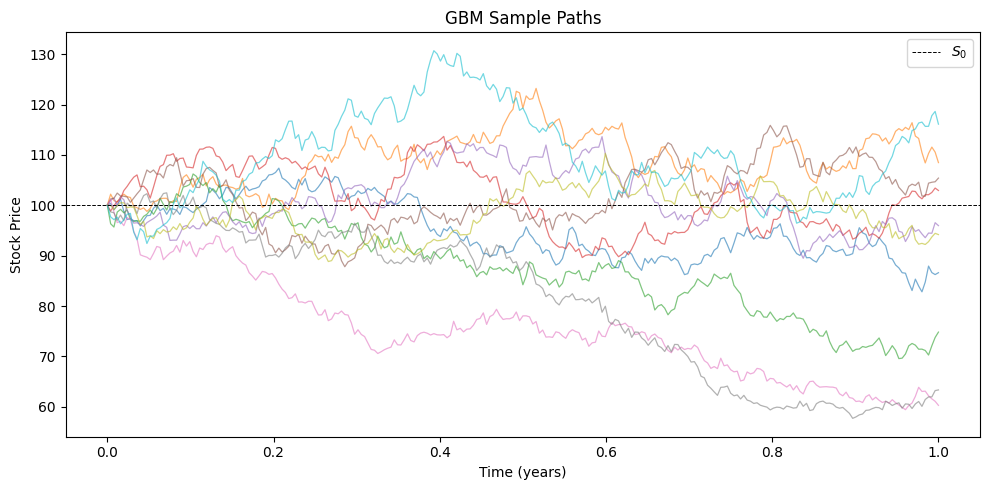

In [ ]:
# ── Simulating GBM paths to visualise the dynamics ────────────────────
rng = np.random.default_rng(42)
n_paths, n_steps = 10, 252
dt_step = T / n_steps
t_grid = np.linspace(0, T, n_steps + 1)

# Simulate under the risk-neutral measure (μ → r − q); see Section 5 for why
drift = (r - q - 0.5 * sigma**2) * dt_step
diffusion = sigma * np.sqrt(dt_step)
log_increments = drift + diffusion * rng.standard_normal((n_paths, n_steps))
log_paths = np.log(S0) + np.cumsum(log_increments, axis=1)
paths = np.column_stack([np.full(n_paths, S0), np.exp(log_paths)])

fig, ax = plt.subplots(figsize=(10, 5))
for i in range(n_paths):
    ax.plot(t_grid, paths[i], alpha=0.6, linewidth=0.9)
ax.axhline(S0, color="black", linestyle="--", linewidth=0.7, label="$S_0$")
ax.set(xlabel="Time (years)", ylabel="Stock Price", title="GBM Sample Paths")
ax.legend()
plt.tight_layout()
plt.show()

## 3) Dynamics of a Contingent Claim — Itô's Lemma

Let $V(S, t)$ be the value of a **contingent claim** (e.g. a European option) that depends on
the stock price $S$ and time $t$.

Because $S$ follows an Itô process, the ordinary chain rule is not valid, and we must instead use **Itô's lemma** to compute $dV$ (see Appendix A for the full statement):

$$dV = \left(\frac{\partial V}{\partial S}\,\mu S + \frac{\partial V}{\partial t} + \frac{1}{2}\,\frac{\partial^2 V}{\partial S^2}\,\sigma^2 S^2\right)dt + \frac{\partial V}{\partial S}\,\sigma S\,dz.$$

In **discrete time** — replacing $d$ with $\Delta$ for small but finite increments:

$$\Delta V \approx \frac{\partial V}{\partial S}\,\Delta S + \frac{\partial V}{\partial t}\,\Delta t + \frac{1}{2}\,\frac{\partial^2 V}{\partial S^2}\,(\Delta S)^2.$$

where $(\Delta S)^2 \approx \sigma^2 S^2 \Delta t$ to leading order (from the quadratic
variation of Brownian motion: $(dz)^2 = dt$). Note, the coefficient on $\frac{\partial V}{\partial S}$ is just the stock increment itself since $\mu S\,\Delta t + \sigma S\,\Delta z = \Delta S$.


> **Key observation:** The derivative $V$ has a **second-order term**
> $\tfrac{1}{2}\frac{\partial^2 V}{\partial S^2}\sigma^2 S^2\,dt$ that is absent in ordinary
> calculus.  This is the hallmark of Itô calculus and it will
> generate the $\Gamma$ term in the BSM PDE.

## 4) Constructing a Riskless Portfolio — Delta Hedging

The critical step in the BSM derivation is to build a portfolio that is **instantaneously
riskless** — i.e. the random $dz$ term cancels out.

Consider a portfolio $\Pi$ that is:
- **Short one derivative** (value $-V$)
- **Long $\frac{\partial V}{\partial S}$ shares** of the underlying

$$\Pi = -V + \frac{\partial V}{\partial S}\,S.$$

Intuitively, $\frac{\partial V}{\partial S}$ is chosen because it is the coefficient on the
first-order stock move in the Taylor/Itô expansion of $V$.  Matching that coefficient is what
makes the $\Delta z$ exposure cancel in the hedged portfolio.

The **change** in the portfolio value, over a small time interval $\Delta t$ is:

$$\Delta\Pi = -\Delta V + \frac{\partial V}{\partial S}\,\Delta S.$$

Now substitute the expressions from Sections 2 and 3.  From Section 2:

$$\Delta S = \mu\,S\,\Delta t + \sigma\,S\,\Delta z.$$

From Section 3 (Itô's lemma in discrete form):

$$\Delta V = \frac{\partial V}{\partial S}\,\mu S\,\Delta t + \frac{\partial V}{\partial t}\,\Delta t + \frac{1}{2}\,\frac{\partial^2 V}{\partial S^2}\,\sigma^2 S^2\,\Delta t + \frac{\partial V}{\partial S}\,\sigma S\,\Delta z.$$

Substituting both into $\Delta\Pi$:

$$\Delta\Pi = -\left[\frac{\partial V}{\partial S}\,\mu S\,\Delta t + \frac{\partial V}{\partial t}\,\Delta t + \frac{1}{2}\,\frac{\partial^2 V}{\partial S^2}\,\sigma^2 S^2\,\Delta t + \frac{\partial V}{\partial S}\,\sigma S\,\Delta z\right] + \frac{\partial V}{\partial S}\left[\mu\,S\,\Delta t + \sigma\,S\,\Delta z\right].$$

Expanding and cancelling — all terms involving $\mu S \frac{\partial V}{\partial S}$ cancel,
and **crucially the stochastic terms $\pm\frac{\partial V}{\partial S}\sigma S\,\Delta z$
cancel**:

$$\boxed{\Delta\Pi = -\frac{\partial V}{\partial t}\,\Delta t - \frac{1}{2}\,\frac{\partial^2 V}{\partial S^2}\,\sigma^2 S^2\,\Delta t.}$$

The portfolio change is **entirely deterministic** — there is no $\Delta z$ term.
The randomness has been perfectly hedged away.

## 5) The Black–Scholes–Merton PDE

Since $\Pi$ is riskless over the interval $\Delta t$, **no-arbitrage** requires it to earn the
risk-free rate:

$$\Delta\Pi = r\,\Pi\,\Delta t.$$

Substituting $\Pi = -V + \frac{\partial V}{\partial S}\,S$ and the deterministic
$\Delta\Pi$ above:

$$-\frac{\partial V}{\partial t}\,\Delta t - \frac{1}{2}\sigma^2 S^2\frac{\partial^2 V}{\partial S^2}\,\Delta t = r\left(-V + \frac{\partial V}{\partial S}\,S\right)\Delta t.$$

Dividing through by $\Delta t$ and rearranging:

$$\boxed{\frac{\partial V}{\partial t} + r\,S\,\frac{\partial V}{\partial S} + \frac{1}{2}\,\sigma^2\,S^2\,\frac{\partial^2 V}{\partial S^2} = r\,V.}$$

This is the **Black–Scholes–Merton PDE** (for an underlying paying no dividends).

> **Important observations:**
> - The expected return $\mu$ does **not** appear — the PDE is the same regardless of
>   investors' risk preferences.  This is the basis of **risk-neutral pricing**.
> - The PDE holds for *any* derivative whose payoff depends only on $S$ and $t$
>   (European calls, puts, digitals, etc.); the specific derivative is determined by the
>   **boundary conditions**.

### With a continuous dividend yield $q$

If the underlying pays a continuous dividend yield $q$, the cost of carry becomes $r - q$:
the share provides income at rate $q$, reducing the required growth.  In the delta-hedging
argument the holder of $\frac{\partial V}{\partial S}$ shares also receives dividends at rate
$q S \frac{\partial V}{\partial S}\,dt$.  The PDE generalises to

$$\boxed{\frac{\partial V}{\partial t} + (r - q)\,S\,\frac{\partial V}{\partial S} + \frac{1}{2}\,\sigma^2\,S^2\,\frac{\partial^2 V}{\partial S^2} = r\,V.}$$

This is the form we use throughout.

## 6) Boundary Conditions

The PDE alone admits infinitely many solutions.  A **unique** solution is selected by imposing
boundary conditions that encode the specific derivative contract.

### Terminal condition (payoff at maturity)

At expiry $t = T$:

| Type | Payoff $V(S, T)$ |
|------|------------------|
| Call | $\max(S_T - K,\ 0)$ |
| Put  | $\max(K - S_T,\ 0)$ |

### Spatial boundary conditions

As $S \to 0$ and $S \to \infty$:

| Boundary | Call | Put |
|----------|------|-----|
| $S \to 0$ | $V \to 0$ | $V \to K\,e^{-r\tau}$ |
| $S \to \infty$ | $V \to S\,e^{-q\tau} - K\,e^{-r\tau}$ | $V \to 0$ |

(Here $\tau = T - t$ is the time to maturity and $S$ is the spatial variable of the PDE.)

The terminal condition combined with these boundary conditions yields a **unique solution**
to the BSM PDE — which can be expressed in closed form (see next section).

In the PDE tutorial, we solve the PDE numerically via finite differences.  Here, we go straight
to the analytical solution.

## 7) Closed-Form Call and Put Formulas

Solving the BSM PDE with the call boundary condition yields the
**Black–Scholes–Merton formula** for a European call on a stock paying a continuous
dividend yield $q$.

$$\boxed{C = S_0\,e^{-qT}\,N(d_1) - K\,e^{-rT}\,N(d_2)}$$

where $N(\cdot)$ is the cumulative standard normal distribution function and

$$d_1 = \frac{\ln(S_0/K) + (r - q + \tfrac{1}{2}\sigma^2)\,T}{\sigma\sqrt{T}}, \qquad d_2 = d_1 - \sigma\sqrt{T}.$$

> **Generalisation to arbitrary valuation date $t$.**  Throughout this notebook we price at
> time $0$ with maturity $T$.  To price at any time $t < T$, replace $T$ with the
> time to maturity $\tau = T - t$ and $S_0$ with $S_t$.  All formulas carry over unchanged.

The formula has a clean interpretation:

| Term | Meaning |
|------|---------|
| $S_0\,e^{-qT}\,N(d_1)$ | PV of the stock-leg contribution. |
| $K\,e^{-rT}\,N(d_2)$ | PV of what you **pay** — the discounted strike, weighted by $N(d_2)$, the risk-neutral probability that the call expires ITM. |

### Put option formula from put–call parity

Rather than re-solving the PDE, we can obtain the put formula directly from the call via
**put–call parity** (Section 9):

$$C - P = S_0\,e^{-qT} - K\,e^{-rT}.$$

Rearranging:

$$P = C - S_0\,e^{-qT} + K\,e^{-rT}.$$

Substituting the call formula and using $N(-x) = 1 - N(x)$:

$$\boxed{P = K\,e^{-rT}\,N(-d_2) - S_0\,e^{-qT}\,N(-d_1)}$$

with the same $d_1$, $d_2$ as before.

In [ ]:
# ── Manual BSM calculation to verify understanding ────────────────────
df_r = np.exp(-r * T)  # risk-free discount factor
df_q = np.exp(-q * T)  # dividend discount factor

d1 = (np.log(S0 / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
d2 = d1 - sigma * np.sqrt(T)

call_price = S0 * df_q * norm.cdf(d1) - K * df_r * norm.cdf(d2)
put_price = K * df_r * norm.cdf(-d2) - S0 * df_q * norm.cdf(-d1)

print(f"d1 = {d1:.6f},  d2 = {d2:.6f}")
print(f"N(d1) = {norm.cdf(d1):.6f},  N(d2) = {norm.cdf(d2):.6f}")
print()
print(f"Call price (manual): {call_price:.6f}")
print(f"Put price  (manual): {put_price:.6f}")

d1 = 0.250000,  d2 = 0.050000
N(d1) = 0.598706,  N(d2) = 0.519939

Call price (manual): 9.227006
Put price  (manual): 6.330081


## 8) Forward-Price Form of $d_1$ and $d_2$

The no-arbitrage **forward price** of the underlying (with continuous dividend yield) is:

$$F_0 = S_0\,e^{(r - q)\,T} = \frac{S_0\,e^{-qT}}{e^{-rT}}.$$

We can rewrite $d_1$ and $d_2$ in terms of $F_0$:

$$d_1 = \frac{\ln(F_0 / K) + \tfrac{1}{2}\sigma^2\,T}{\sigma\sqrt{T}}, \qquad d_2 = \frac{\ln(F_0 / K) - \tfrac{1}{2}\sigma^2\,T}{\sigma\sqrt{T}}.$$

And the call formula becomes:

$$C = e^{-rT}\left[F_0\,N(d_1) - K\,N(d_2)\right].$$

This is the **Black (1976) formula** and is the natural form when working with forwards or
futures (e.g. interest-rate caplets, commodity options).  It separates discounting from the
forward-vs-strike comparison.

**Why it matters:**
- For options on **spot assets** such as commodities, rates, or FX-related underlyings,
  practitioners often observe a forward or futures curve directly.  In that case it can be
  more natural to use the observed $F_0$ than to infer a convenience yield or other
  cost-of-carry input and then reconstruct the forward from $S_0$, $r$, and $q$.
- For **options on futures contracts**, the same Black '76 formula applies with the current
  futures price as the forward input.  In the spot-style BSM notation used earlier, this is
  equivalent to setting $q = r$ and replacing $S_0$ by the current futures price, so the
  carry term vanishes and $F_0 = S_0$.
- The forward form makes it transparent that only the **ratio $F_0/K$** and volatility
  determine the option moneyness.

In [ ]:
# ── Forward-price form: same numbers, different route ─────────────────
F0 = S0 * np.exp((r - q) * T)  # = S_0 * df_q / df_r
d1_fwd = (np.log(F0 / K) + 0.5 * sigma**2 * T) / (sigma * np.sqrt(T))
d2_fwd = (np.log(F0 / K) - 0.5 * sigma**2 * T) / (sigma * np.sqrt(T))

call_fwd = df_r * (F0 * norm.cdf(d1_fwd) - K * norm.cdf(d2_fwd))

print(f"Forward price F_0 = {F0:.6f}")
print(f"d1 (forward form) = {d1_fwd:.6f}  (matches d1 = {d1:.6f})")
print(f"d2 (forward form) = {d2_fwd:.6f}  (matches d2 = {d2:.6f})")
print(f"Call (forward form): {call_fwd:.6f}  (matches call = {call_price:.6f})")

# Verify via the library's forward_price utility
F0_lib = forward_price(
    spot=S0,
    pricing_date=pricing_date,
    maturity=maturity,
    discount_curve=curve_r,
    dividend_curve=curve_q,
)
print(f"\nForward price (library): {F0_lib:.6f}")

Forward price F_0 = 103.045453
d1 (forward form) = 0.250000  (matches d1 = 0.250000)
d2 (forward form) = 0.050000  (matches d2 = 0.050000)
Call (forward form): 9.227006  (matches call = 9.227006)

Forward price (library): 103.045453


## 9) Put–Call Parity

For European options on a dividend-paying stock, **put–call parity** is:

$$C - P = S_0\,e^{-qT} - K\,e^{-rT} = e^{-rT}(F_0 - K).$$

This is a **no-arbitrage relationship** — it holds regardless of the pricing model.  It
connects the call and put prices to the forward price and the discounted strike.

If the relationship is violated, an arbitrageur can lock in a riskless profit by holding a
suitable combination of the call, put, bond, and stock.

In [ ]:
# ── Verify put–call parity ────────────────────────────────────────────
lhs = call_price - put_price
rhs = S0 * df_q - K * df_r
print(f"C - P      = {lhs:.6f}")
print(f"S_0 e^{{-qT}} - K e^{{-rT}} = {rhs:.6f}")
print(f"Difference = {abs(lhs - rhs):.2e}")

# Also via the library utility
parity_gap = put_call_parity_gap(
    call_price=call_price,
    put_price=put_price,
    spot=S0,
    strike=K,
    pricing_date=pricing_date,
    maturity=maturity,
    discount_curve=curve_r,
    dividend_curve=curve_q,
)
print(f"Put-call parity gap (library): {parity_gap:.2e}")
print("(any residual at ~1e-15 is floating-point rounding, not a pricing error)")

C - P      = 2.896925
S_0 e^{-qT} - K e^{-rT} = 2.896925
Difference = 0.00e+00
Put-call parity gap (library): 1.78e-15
(any residual at ~1e-15 is floating-point rounding, not a pricing error)


## 10) Pricing with `derivatives_pricing`

The library's `OptionValuation` class dispatches to the analytical BSM engine when
`PricingMethod.BSM` is selected.  The engine internally computes $d_1$, $d_2$, discount
factors, and returns the Black–Scholes price.

In [ ]:
# ── Price via the library ─────────────────────────────────────────────
ov_call = dp.OptionValuation(
    underlying=underlying,
    spec=spec_call,
    pricing_method=dp.PricingMethod.BSM,
)

ov_put = dp.OptionValuation(
    underlying=underlying,
    spec=spec_put,
    pricing_method=dp.PricingMethod.BSM,
)

lib_call = ov_call.present_value()
lib_put = ov_put.present_value()

print(f"Library call: {lib_call:.6f}  (manual: {call_price:.6f})")
print(f"Library put:  {lib_put:.6f}  (manual: {put_price:.6f})")

Library call: 9.227006  (manual: 9.227006)
Library put:  6.330081  (manual: 6.330081)


## 11) Garman–Kohlhagen — FX Options as a Special Case

The BSM formula with a continuous dividend yield is versatile.  **Garman and
Kohlhagen (1983)** observed that a foreign-exchange option can be priced with exactly the
same formula by interpreting the parameters as follows:

| BSM parameter | FX interpretation |
|---|---|
| $S_0$ | Spot exchange rate (domestic per unit of foreign currency) |
| $r$ | **Domestic** risk-free rate |
| $q$ | **Foreign** risk-free rate |
| $\sigma$ | Volatility of the exchange rate |

The reasoning: holding one unit of foreign currency earns the foreign risk-free rate $r_f$,
which plays the same role as a continuous dividend yield on a stock.  Substituting
$q \to r_f$ reproduces the Garman–Kohlhagen formula:

$$C_{\text{FX}} = S_0\,e^{-r_f T}\,N(d_1) - K\,e^{-r_d T}\,N(d_2)$$

with

$$d_1 = \frac{\ln(S_0 / K) + (r_d - r_f + \tfrac{1}{2}\sigma^2)\,T}{\sigma\sqrt{T}}.$$

To price an FX option using the `derivatives_pricing` library, set the domestic rate curve
as the discount curve and the foreign rate curve as the dividend curve.

In [ ]:
# ── FX option example: EUR/USD call ──────────────────────────────────
S_fx = 1.08  # EUR/USD spot
K_fx = 1.10  # strike
sigma_fx = 0.08  # FX vol
r_d = 0.045  # USD (domestic) rate
r_f = 0.035  # EUR (foreign) rate

curve_domestic = dp.DiscountCurve.flat(r_d, end_time=T)
curve_foreign = dp.DiscountCurve.flat(r_f, end_time=T)

market_fx = dp.MarketData(pricing_date, curve_domestic, currency="USD")

underlying_fx = dp.UnderlyingData(
    initial_value=S_fx,
    volatility=sigma_fx,
    market_data=market_fx,
    dividend_curve=curve_foreign,  # foreign rate plays role of div yield
)

spec_fx_call = dp.VanillaSpec(
    option_type=dp.OptionType.CALL,
    exercise_type=dp.ExerciseType.EUROPEAN,
    strike=K_fx,
    maturity=maturity,
    currency="USD",
)

ov_fx = dp.OptionValuation(
    underlying=underlying_fx,
    spec=spec_fx_call,
    pricing_method=dp.PricingMethod.BSM,
)

# Manual Garman–Kohlhagen for verification
df_d = np.exp(-r_d * T)
df_f = np.exp(-r_f * T)
d1_fx = (np.log(S_fx / K_fx) + (r_d - r_f + 0.5 * sigma_fx**2) * T) / (sigma_fx * np.sqrt(T))
d2_fx = d1_fx - sigma_fx * np.sqrt(T)
gk_call = S_fx * df_f * norm.cdf(d1_fx) - K_fx * df_d * norm.cdf(d2_fx)

print(f"EUR/USD call (library):            {ov_fx.present_value():.6f}")
print(f"EUR/USD call (Garman–Kohlhagen):   {gk_call:.6f}")

EUR/USD call (library):            0.029224
EUR/USD call (Garman–Kohlhagen):   0.029224


## 12) Greeks — Analytical Sensitivities

The BSM model admits **closed-form Greeks** — partial derivatives of the option price with
respect to the underlying parameters.  Because the formulas are analytical, they are exact
(no numerical error) and fast to compute.

In the table below, greeks are shown in their standard textbook units. The `derivatives_pricing`
library reports **vega per 1 volatility point** (so divide textbook vega by 100),
**rho per 1% rate change** (divide textbook rho by 100), and **theta per day**
(divide annual theta by 365).

| Greek | Symbol | Call | Put |
|-------|--------|------|-----|
| **Delta** | $\Delta$ | $e^{-qT}\,N(d_1)$ | $-e^{-qT}\,N(-d_1)$ |
| **Gamma** | $\Gamma$ | $\dfrac{e^{-qT}\,N'(d_1)}{S_0\,\sigma\sqrt{T}}$ | same as call |
| **Vega** | $\mathcal{V}$ | $S_0\,e^{-qT}\,N'(d_1)\sqrt{T}$ | same as call |
| **Theta** | $\Theta$ | $-\dfrac{S_0 e^{-qT} N'(d_1)\sigma}{2\sqrt{T}} - rKe^{-rT}N(d_2) + qS_0 e^{-qT}N(d_1)$ | $-\dfrac{S_0 e^{-qT} N'(d_1)\sigma}{2\sqrt{T}} + rKe^{-rT}N(-d_2) - qS_0 e^{-qT}N(-d_1)$ |
| **Rho** | $\rho$ | $K\,T\,e^{-rT}\,N(d_2)$ | $-K\,T\,e^{-rT}\,N(-d_2)$ |

where $N'(x) = \frac{1}{\sqrt{2\pi}}e^{-x^2/2}$ is the standard normal PDF.

In [ ]:
# ── Greeks via the library ────────────────────────────────────────────
greeks_call = {
    "delta": ov_call.delta(),
    "gamma": ov_call.gamma(),
    "vega": ov_call.vega(),
    "theta": ov_call.theta(),
    "rho": ov_call.rho(),
}
greeks_put = {
    "delta": ov_put.delta(),
    "gamma": ov_put.gamma(),
    "vega": ov_put.vega(),
    "theta": ov_put.theta(),
    "rho": ov_put.rho(),
}

print(f"{'Greek':>8s}    {'Call':>10s}    {'Put':>10s}")
print("-" * 36)
for g in greeks_call:
    print(f"{g:>8s}    {greeks_call[g]:10.6f}    {greeks_put[g]:10.6f}")

   Greek          Call           Put
------------------------------------
   delta      0.586851     -0.393348
   gamma      0.018951      0.018951
    vega      0.379012      0.379012
   theta     -0.013943     -0.006284
     rho      0.494581     -0.456648


In [ ]:
# ── Manual verification of call greeks ───────────────────────
delta_manual = df_q * norm.cdf(d1)
gamma_manual = df_q * norm.pdf(d1) / (S0 * sigma * np.sqrt(T))
rho_manual = K * T * df_r * norm.cdf(d2) / 100  # per 1% rate change
vega_manual = S0 * df_q * norm.pdf(d1) * np.sqrt(T) / 100  # per 1% vol point
theta_manual = (
    -(S0 * df_q * norm.pdf(d1) * sigma / (2 * np.sqrt(T)))
    - r * K * df_r * norm.cdf(d2)
    + q * S0 * df_q * norm.cdf(d1)
) / 365  # per day

print(f"Delta (manual): {delta_manual:.6f}  (library: {greeks_call['delta']:.6f})")
print(f"Gamma (manual): {gamma_manual:.6f}  (library: {greeks_call['gamma']:.6f})")
print(f"Vega  (manual): {vega_manual:.6f}  (library: {greeks_call['vega']:.6f})")
print(f"Theta (manual): {theta_manual:.6f}  (library: {greeks_call['theta']:.6f})")
print(f"Rho   (manual): {rho_manual:.6f}  (library: {greeks_call['rho']:.6f})")

Delta (manual): 0.586851  (library: 0.586851)
Gamma (manual): 0.018951  (library: 0.018951)
Vega  (manual): 0.379012  (library: 0.379012)
Theta (manual): -0.013943  (library: -0.013943)
Rho   (manual): 0.494581  (library: 0.494581)


### Visualising delta and gamma across spot prices

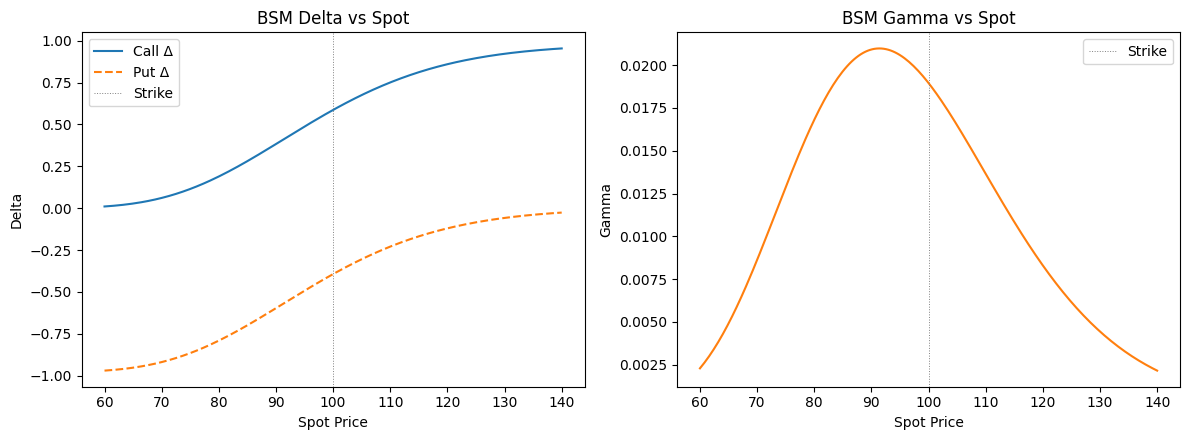

In [ ]:
spots = np.linspace(60, 140, 200)

deltas_call = []
deltas_put = []
gammas = []

for s in spots:
    d1_s = (np.log(s / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    deltas_call.append(df_q * norm.cdf(d1_s))
    deltas_put.append(df_q * (norm.cdf(d1_s) - 1))
    gammas.append(df_q * norm.pdf(d1_s) / (s * sigma * np.sqrt(T)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

ax1.plot(spots, deltas_call, label="Call Δ")
ax1.plot(spots, deltas_put, label="Put Δ", linestyle="--")
ax1.axvline(K, color="grey", linestyle=":", linewidth=0.7, label="Strike")
ax1.set(xlabel="Spot Price", ylabel="Delta", title="BSM Delta vs Spot")
ax1.legend()

ax2.plot(spots, gammas, color="tab:orange")
ax2.axvline(K, color="grey", linestyle=":", linewidth=0.7, label="Strike")

ax2.set(xlabel="Spot Price", ylabel="Gamma", title="BSM Gamma vs Spot")
ax2.legend()

plt.tight_layout()
plt.show()

## 13) Implied Volatility

In practice, traders observe **market prices** of options and back out the volatility that,
when plugged into the BSM formula, reproduces the observed price.  This is the **implied
volatility** $\sigma_{\text{imp}}$.

Formally, given an observed option price $V^{\text{mkt}}$, the implied volatility solves:

$$V^{\text{BSM}}(S_0, K, r, q, T,\;\sigma_{\text{imp}}) = V^{\text{mkt}}.$$

Since there is no closed-form inverse, this requires a **numerical root-finding** algorithm.
Popular approaches include Newton–Raphson (using vega as the derivative), Brent's method,
and rational approximation initialisers (e.g. Jäckel 2015).

The `derivatives_pricing` library provides an `implied_volatility` function that handles this:

In [ ]:
# ── Implied volatility round-trip ─────────────────────────────────────
# Start from the BSM price and recover sigma.
# We deliberately use an initial guess that is not the true volatility.
target_price = lib_call  # the BSM call price at sigma = 0.20

iv_result = dp.implied_volatility(target_price, ov_call, initial_vol=0.35)

print(f"Input σ:          {sigma:.6f}")
print("Initial guess:     0.350000")
print(f"Recovered IV:     {iv_result.implied_vol:.6f}")
print(f"Converged:        {iv_result.converged}")
print(f"Round-trip error:  {abs(iv_result.implied_vol - sigma):.2e}")

Input σ:          0.200000
Initial guess:     0.350000
Recovered IV:     0.200000
Converged:        True
Round-trip error:  4.16e-16


### The volatility smile / skew

If the BSM model were perfectly correct, implied volatility would be the same for all strikes
and maturities.  In reality, market-implied vols vary with strike (the **smile** or **skew**)
and with maturity (the **term structure**).

This tells us that:
- The true return distribution has **fatter tails** (and often negative skewness) compared to
  the lognormal assumption.
- Volatility is not constant — it clusters and exhibits mean-reversion (see Heston, SABR,
  local-volatility models).

Despite its limitations, BSM implied volatility remains the standard quoting convention
across options markets — prices are quoted as BSM implied vols even when the model itself
is known to be an approximation.

## 14) Visualising the BSM Surface

The BSM call value as a function of spot $S_0$ and time to maturity $\tau = T - t$.

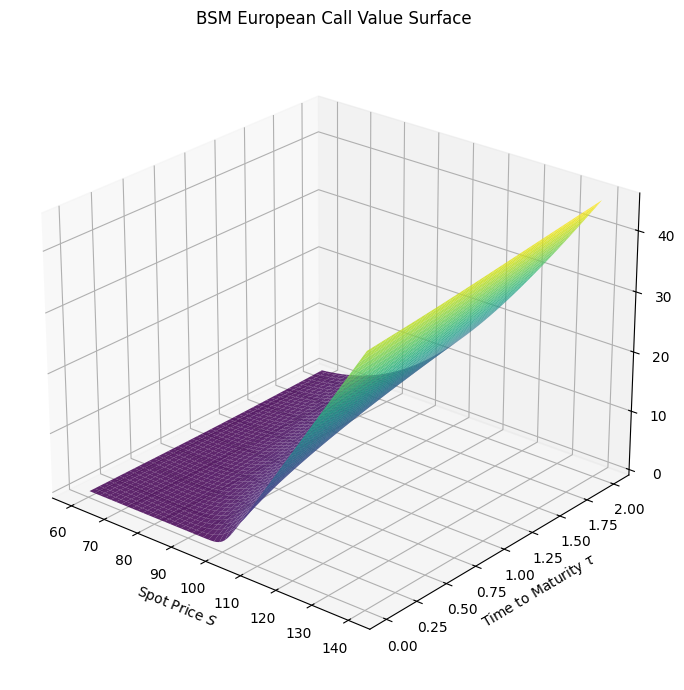

In [ ]:
spots_grid = np.linspace(60, 140, 100)
taus_grid = np.linspace(0.01, 2.0, 100)
S_mesh, Tau_mesh = np.meshgrid(spots_grid, taus_grid)

# Vectorised BSM call computation
d1_mesh = (np.log(S_mesh / K) + (r - q + 0.5 * sigma**2) * Tau_mesh) / (sigma * np.sqrt(Tau_mesh))
d2_mesh = d1_mesh - sigma * np.sqrt(Tau_mesh)
C_mesh = S_mesh * np.exp(-q * Tau_mesh) * norm.cdf(d1_mesh) - K * np.exp(-r * Tau_mesh) * norm.cdf(
    d2_mesh
)

fig, ax = plt.subplots(figsize=(10, 7), subplot_kw={"projection": "3d"})
ax.plot_surface(S_mesh, Tau_mesh, C_mesh, cmap="viridis", alpha=0.85, edgecolor="none")
ax.set(
    xlabel="Spot Price $S$",
    ylabel="Time to Maturity $\\tau$",
    zlabel="Call Value $C$",
    title="BSM European Call Value Surface",
)
ax.view_init(elev=25, azim=-50)
plt.tight_layout()
plt.show()

## 15) Discrete Dividends — The Escrowed-Dividend Approach

So far we have modelled dividends as a **continuous yield** $q$.  In practice, equities pay
**discrete cash dividends** on known ex-dates.  The BSM closed-form solution does not directly
handle discrete dividends, but we can use an approximation: the
**escrowed-dividend** (or **prepaid-forward**) adjustment.

### The idea

On each ex-dividend date, the stock price drops by the dividend amount.  We can separate the
stock price into two components:

1. The **present value of all known future dividends** on or before maturity — a deterministic,
   riskless cash flow.
2. The **residual stochastic component** — the part that actually follows GBM.

The escrowed-dividend approach subtracts the PV of the discrete dividends from the spot
to obtain the **adjusted spot**:

$$S^* = S_0 - \sum_{i:\,t_i \le T} D_i\,P(0,t_i),$$

where $D_i$ is the cash dividend at ex-date $t_i$ and $P(0,t_i)$ is the risk-free discount
factor to that date.  Under a flat rate, $P(0,t_i) = e^{-r t_i}$.  We then pass
$S^*$ into the standard BSM formula in place of $S_0$, with $q = 0$ (since the dividends have
already been "escrowed" out).

This is an approximation — it ignores the fact that the volatility of the full stock price
differs from the volatility of the residual component.  See the note on the volatility
adjustment below.

### Pricing in the library

The `UnderlyingData` class accepts a `discrete_dividends` parameter — a sequence of
`(ex_date, amount)` pairs.  The BSM engine automatically applies the escrowed-dividend
adjustment via `pv_discrete_dividends()`.

In [ ]:
# ── Discrete dividend example ─────────────────────────────────────────
div_dates = [
    (dt.datetime(2025, 4, 1), 1.50),  # ex-date 1: $1.50
    (dt.datetime(2025, 10, 1), 1.50),  # ex-date 2: $1.50
]

# No continuous yield — dividends are fully discrete
underlying_disc = dp.UnderlyingData(
    initial_value=S0,
    volatility=sigma,
    market_data=market_data,
    discrete_dividends=div_dates,
)

ov_call_disc = dp.OptionValuation(
    underlying=underlying_disc,
    spec=spec_call,
    pricing_method=dp.PricingMethod.BSM,
)

ov_put_disc = dp.OptionValuation(
    underlying=underlying_disc,
    spec=spec_put,
    pricing_method=dp.PricingMethod.BSM,
)

print(f"Call (discrete divs): {ov_call_disc.present_value():.6f}")
print(f"Put  (discrete divs): {ov_put_disc.present_value():.6f}")
print()

# ── Show the escrowed-dividend mechanics ──────────────────────────────
pv_divs = pv_discrete_dividends(
    dividends=div_dates,
    curve_date=pricing_date,
    end_date=maturity,
    discount_curve=curve_r,
)
S_star = S0 - pv_divs

print(f"PV of discrete dividends: {pv_divs:.6f}")
print(f"Adjusted spot S* = S_0 - PV(divs) = {S0} - {pv_divs:.4f} = {S_star:.6f}")

Call (discrete divs): 8.669270
Put  (discrete divs): 6.718772

PV of discrete dividends: 2.926560
Adjusted spot S* = S_0 - PV(divs) = 100.0 - 2.9266 = 97.073440


In [ ]:
# ── Manual BSM with adjusted spot (q = 0) ─────────────────────────────
d1_disc = (np.log(S_star / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
d2_disc = d1_disc - sigma * np.sqrt(T)

call_disc_manual = S_star * norm.cdf(d1_disc) - K * df_r * norm.cdf(d2_disc)
put_disc_manual = K * df_r * norm.cdf(-d2_disc) - S_star * norm.cdf(-d1_disc)

print(
    f"Call (manual, escrowed): {call_disc_manual:.6f}  (library: {ov_call_disc.present_value():.6f})"
)
print(
    f"Put  (manual, escrowed): {put_disc_manual:.6f}  (library: {ov_put_disc.present_value():.6f})"
)

Call (manual, escrowed): 8.669270  (library: 8.669270)
Put  (manual, escrowed): 6.718772  (library: 6.718772)


### Volatility adjustment (optional refinement)

The escrowed-dividend approach uses the **original** $\sigma$ applied to the adjusted
spot $S^*$.  Strictly, the volatility of $S^*$ is higher than that of $S_0$ because we
removed a riskless component while keeping essentially the same dollar diffusion term.
A common heuristic correction therefore scales vol upward:

$$\sigma^* = \sigma \cdot \frac{S_0}{S^*}.$$

This is a rule of thumb rather than an exact identity. In practice it can move the escrowed-dividend BSM price closer to methods that model the dividend jumps directly, although that is empirical rather than guaranteed.

In [ ]:
# ── Volatility-adjusted comparison ────────────────────────────────────
sigma_adj = sigma * S0 / S_star
print(f"Original σ:  {sigma:.6f}")
print(f"Adjusted σ*: {sigma_adj:.6f}")

underlying_adj = underlying_disc.replace(volatility=sigma_adj)
ov_call_adj = dp.OptionValuation(
    underlying=underlying_adj,
    spec=spec_call,
    pricing_method=dp.PricingMethod.BSM,
)
print(f"\nCall (escrowed, original σ):  {ov_call_disc.present_value():.6f}")
print(f"Call (escrowed, adjusted σ*): {ov_call_adj.present_value():.6f}")

Original σ:  0.200000
Adjusted σ*: 0.206030

Call (escrowed, original σ):  8.669270
Call (escrowed, adjusted σ*): 8.898083


## 16) Non-Flat Discount and Dividend Curves

Sections 1–14 used **flat** (constant) rates: $r$ for discounting and $q$ for the continuous
dividend yield.  With non-flat but deterministic curves, the cleanest way to write BSM is not
in terms of constant $r$ and $q$, but in terms of the associated discount factors and forward
price:

| Flat-rate form | Curve-based generalisation |
|---|---|
| $e^{-rT}$ (risk-free DF) | $P(0, T) = $ `discount_curve.df(T)` |
| $e^{-qT}$ (dividend DF) | $D_q(0, T) = $ `dividend_curve.df(T)` |

When the rates are **time-varying but deterministic**, these closed-form discount factors
generalise to:

$$P(0, T) = e^{-\int_0^T r(u)\,du}, \qquad D_q(0, T) = e^{-\int_0^T q(u)\,du}.$$

If you start from the spot-based formula, the drift term in $d_1$ becomes the integrated
carry:

$$d_1 = \frac{\ln(S_0/K) + \int_0^T (r(u)-q(u))\,du + \tfrac{1}{2}\sigma^2 T}{\sigma\sqrt{T}}.$$

Since

$$\int_0^T (r(u)-q(u))\,du = -\ln P(0,T) + \ln D_q(0,T) = \ln\!\left(\frac{D_q(0,T)}{P(0,T)}\right),$$

this is exactly equivalent to the forward-based form

$$d_1 = \frac{\ln(F_0/K) + \tfrac{1}{2}\sigma^2 T}{\sigma\sqrt{T}}, \qquad F_0 = \frac{S_0 D_q(0,T)}{P(0,T)}.$$

That is the form used internally by the library: `DiscountCurve` stores discount factors
directly, the BSM engine builds the forward from `df_q / df_r`, and then computes $d_1$ and
$d_2$ from that forward.  So the generalisation to non-flat deterministic rates does not
change the model structure.

### Forward price under non-flat curves

The forward price becomes:

$$F_0 = \frac{S_0 \cdot D_q(0,T)}{P(0,T)},$$

which reduces to $S_0 e^{(r-q)T}$ when both curves are flat.  The BSM $d_1$ and $d_2$
in forward form remain:

$$d_1 = \frac{\ln(F_0/K) + \tfrac{1}{2}\sigma^2 T}{\sigma\sqrt{T}}, \qquad d_2 = d_1 - \sigma\sqrt{T}.$$

### Building curves in the library

`DiscountCurve` offers several constructors:

| Constructor | Input |
|---|---|
| `DiscountCurve.flat(rate, end_time)` | Flat continuously-compounded rate |
| `DiscountCurve.from_zero_rates(times, zero_rates)` | Zero (spot) rates at each tenor |
| `DiscountCurve.from_forwards(times, forwards)` | Piecewise-constant forward rates |
| `DiscountCurve(times, dfs)` | Raw discount factors directly |

In [ ]:
# ── Non-flat curve example ────────────────────────────────────────────
# Upward-sloping risk-free curve via zero rates
tenors = np.array([0.0, 0.25, 0.50, 0.75, 1.0])
zero_rates_r = np.array([0.03, 0.035, 0.04, 0.05, 0.06])
curve_r_nonflat = dp.DiscountCurve.from_zero_rates(tenors, zero_rates_r)

# Dividend yield curve via forward rates (mild upward slope)
fwd_rates_q = np.array([0.015, 0.018, 0.020, 0.022])  # one per interval
curve_q_nonflat = dp.DiscountCurve.from_forwards(tenors, fwd_rates_q)

print("Risk-free discount factors:")
for t in tenors:
    print(f"  P(0, {t:.2f}) = {float(curve_r_nonflat.df(t)):.6f}")

print("\nDividend discount factors:")
for t in tenors:
    print(f"  Dq(0, {t:.2f}) = {float(curve_q_nonflat.df(t)):.6f}")

Risk-free discount factors:
  P(0, 0.00) = 1.000000
  P(0, 0.25) = 0.991288
  P(0, 0.50) = 0.980199
  P(0, 0.75) = 0.963194
  P(0, 1.00) = 0.941765

Dividend discount factors:
  Dq(0, 0.00) = 1.000000
  Dq(0, 0.25) = 0.996257
  Dq(0, 0.50) = 0.991784
  Dq(0, 0.75) = 0.986837
  Dq(0, 1.00) = 0.981425


In [ ]:
# ── Compare flat vs non-flat pricing ──────────────────────────────────
market_nonflat = dp.MarketData(pricing_date, curve_r_nonflat, currency="USD")

underlying_nonflat = dp.UnderlyingData(
    initial_value=S0,
    volatility=sigma,
    market_data=market_nonflat,
    dividend_curve=curve_q_nonflat,
)

ov_call_nonflat = dp.OptionValuation(
    underlying=underlying_nonflat,
    spec=spec_call,
    pricing_method=dp.PricingMethod.BSM,
)
ov_put_nonflat = dp.OptionValuation(
    underlying=underlying_nonflat,
    spec=spec_put,
    pricing_method=dp.PricingMethod.BSM,
)

# Read off the terminal discount factors for comparison
df_r_nf = float(curve_r_nonflat.df(T))
df_q_nf = float(curve_q_nonflat.df(T))

# Forward price under non-flat curves
F0_nonflat = S0 * df_q_nf / df_r_nf

print(f"{'':20s}  {'Flat':>10s}  {'Non-flat':>10s}")
print("-" * 44)
print(f"{'P(0,T)':20s}  {df_r:10.6f}  {df_r_nf:10.6f}")
print(f"{'Dq(0,T)':20s}  {df_q:10.6f}  {df_q_nf:10.6f}")
print(f"{'Forward F_0':20s}  {F0:10.6f}  {F0_nonflat:10.6f}")
print(f"{'Call':20s}  {lib_call:10.6f}  {ov_call_nonflat.present_value():10.6f}")
print(f"{'Put':20s}  {lib_put:10.6f}  {ov_put_nonflat.present_value():10.6f}")

                            Flat    Non-flat
--------------------------------------------
P(0,T)                  0.951229    0.941765
Dq(0,T)                 0.980199    0.981425
Forward F_0           103.045453  104.211260
Call                    9.227006    9.804427
Put                     6.330081    5.838412


In [ ]:
# ── Manual verification with non-flat discount factors ────────────────
d1_nf = (np.log(F0_nonflat / K) + 0.5 * sigma**2 * T) / (sigma * np.sqrt(T))
d2_nf = d1_nf - sigma * np.sqrt(T)

call_nf_manual = df_r_nf * (F0_nonflat * norm.cdf(d1_nf) - K * norm.cdf(d2_nf))
put_nf_manual = df_r_nf * (K * norm.cdf(-d2_nf) - F0_nonflat * norm.cdf(-d1_nf))

print(
    f"Call (manual, non-flat): {call_nf_manual:.6f}  (library: {ov_call_nonflat.present_value():.6f})"
)
print(
    f"Put  (manual, non-flat): {put_nf_manual:.6f}  (library: {ov_put_nonflat.present_value():.6f})"
)

Call (manual, non-flat): 9.804427  (library: 9.804427)
Put  (manual, non-flat): 5.838412  (library: 5.838412)


The key takeaway: the BSM formula generalises to non-flat deterministic curves.
The only inputs that change are the discount factors $P(0,T)$ and $D_q(0,T)$ — the
formula structure remains the same.

## 17) Limitations and Extensions

The BSM model's elegance comes with well-known limitations.  Being aware of these is important
for practitioners:

| Assumption | Reality | Extension |
|---|---|---|
| **Constant volatility** | Vol clusters and has a term structure | Stochastic vol (Heston), local vol, SABR |
| **Lognormal returns** | Fat tails, skewness | Jump-diffusion (Merton 1976), variance-gamma |
| **Continuous trading** | Discrete rebalancing → hedging error | Transaction cost models, discrete hedging bounds |
| **No transaction costs** | Bid–ask spreads, commissions | Leland (1985), Hoggard–Whalley–Wilmott |
| **Constant interest rates** | Yield curve moves | Hull–White, HJM framework |
| **European exercise only** | American exercise is common | Binomial trees, PDE with free boundary, LSM |
| **No dividends / continuous div** | Discrete dividends | Escrowed dividend models, forward-tree adjustments |

Despite these limitations, BSM remains the foundational pricing model.  Every extension
listed above builds on (or translates results back to) the BSM framework.

## 18) Summary

| Topic | Key takeaway |
|---|---|
| **Stock dynamics** | $dS = \mu S\,dt + \sigma S\,dz$ — GBM with constant coefficients |
| **Itô's lemma** | Gives $dV$ for any smooth $V(S,t)$; introduces the second-order $\Gamma$ term |
| **Delta-hedged portfolio** | $\Pi = -V + \frac{\partial V}{\partial S}S$ is instantaneously riskless |
| **BSM PDE** | $\frac{\partial V}{\partial t} + (r-q)S\frac{\partial V}{\partial S} + \frac{1}{2}\sigma^2 S^2\frac{\partial^2 V}{\partial S^2} = rV$ |
| **Boundary conditions** | Terminal payoff + spatial limits → unique solution |
| **Call formula** | $C = S_0 e^{-qT}N(d_1) - Ke^{-rT}N(d_2)$ |
| **Put formula** | $P = Ke^{-rT}N(-d_2) - S_0 e^{-qT}N(-d_1)$ — via put–call parity |
| **Forward form** | $d_1 = \frac{\ln(F_0/K) + \frac{1}{2}\sigma^2 T}{\sigma\sqrt{T}}$ — natural for Black '76 |
| **Put–call parity** | $C - P = e^{-rT}(F_0 - K)$ — model-free no-arbitrage relationship |
| **FX options** | Set $r \to r_d$, $q \to r_f$ (Garman–Kohlhagen) |
| **Greeks** | Closed-form $\Delta$, $\Gamma$, $\mathcal{V}$, $\Theta$, $\rho$ |
| **Implied vol** | Invert BSM numerically — the market's quoting convention |
| **Discrete dividends** | Escrowed-dividend: replace $S_0$ with $S^* = S_0 - \text{PV(divs)}$, set $q=0$ |
| **Non-flat curves** | Replace $e^{-rT}$, $e^{-qT}$ with curve discount factors $P(0,T)$, $D_q(0,T)$ |

**References:**
- Black, F. and Scholes, M. (1973). *The Pricing of Options and Corporate Liabilities*. Journal of Political Economy.
- Merton, R. C. (1973). *Theory of Rational Option Pricing*. Bell Journal of Economics.
- Black, F. (1976). *The Pricing of Commodity Contracts*. Journal of Financial Economics.
- Garman, M. B. and Kohlhagen, S. W. (1983). *Foreign Currency Option Values*. Journal of International Money and Finance.
- Hull, J. C. *Options, Futures, and Other Derivatives*, Chapters 14–15, 17-19.

---

## Appendix A

### A.1 — Itô processes and Itô's lemma

A general **Itô process** for a variable $S$ has the form

$$dS = a(S, t)\,dt + b(S, t)\,dW,$$

where $a(S,t)$ is the **drift** and $b(S,t)$ is the **diffusion coefficient**, both of which
may depend on the current value $S$ and time $t$, and $W$ is a standard Brownian motion.

Let $G(S, t)$ be a twice-differentiable function of $S$ and $t$.  **Itô's lemma** states that

$$\boxed{dG = \left(\frac{\partial G}{\partial S}\,a + \frac{\partial G}{\partial t} + \frac{1}{2}\,\frac{\partial^2 G}{\partial S^2}\,b^2\right)dt + \frac{\partial G}{\partial S}\,b\,dW.}$$

The extra second-order term $\frac{1}{2}\,\frac{\partial^2 G}{\partial S^2}\,b^2$ is the key
difference from ordinary calculus — it arises from Brownian motion's **quadratic variation**:
heuristically $(dW)^2 = dt$ (while $dt\,dW = 0$ and $(dt)^2 = 0$).

### A.2 — Applying Itô's lemma to $G = \ln S$

For **geometric Brownian motion** the SDE is

$$dS = \mu\,S\,dt + \sigma\,S\,dW,$$

so $a(S,t) = \mu S$ and $b(S,t) = \sigma S$.

Choose $G = \ln S$.  The required partial derivatives are:

$$\frac{\partial G}{\partial S} = \frac{1}{S}, \qquad \frac{\partial^2 G}{\partial S^2} = -\frac{1}{S^2}, \qquad \frac{\partial G}{\partial t} = 0.$$

Substituting into Itô's lemma:

$$d(\ln S) = \left(\frac{1}{S}\cdot\mu S + 0 + \frac{1}{2}\left(-\frac{1}{S^2}\right)(\sigma S)^2\right)dt + \frac{1}{S}\cdot\sigma S\,dW$$

$$\boxed{d(\ln S) = \left(\mu - \tfrac{1}{2}\sigma^2\right)dt + \sigma\,dW.}$$

This is the central result: the log-price follows an **arithmetic Brownian motion** with
constant drift $\mu - \frac{1}{2}\sigma^2$ and constant diffusion $\sigma$.  The
$-\frac{1}{2}\sigma^2$ correction (the "Itô correction") is a direct consequence of the
second-order term in Itô's lemma.

### A.3 — Distribution of $\ln S_T$ and the lognormal property

Since $d(\ln S)$ has **constant coefficients**, we can integrate directly from $0$ to $T$:

$$\ln S_T - \ln S_0 = \left(\mu - \tfrac{1}{2}\sigma^2\right)T + \sigma\,W_T.$$

Because $W_T \sim \mathcal{N}(0, T)$, the log-price at maturity is normally distributed:

$$\boxed{\ln S_T \sim \mathcal{N}\!\left(\ln S_0 + \left(\mu - \tfrac{1}{2}\sigma^2\right)T,\;\sigma^2 T\right).}$$

Equivalently, $S_T$ is **lognormally distributed** — this is the distributional foundation of
the Black–Scholes–Merton formula.  The fact that $S_T > 0$ (the exponential of a normal
random variable) is automatically guaranteed.

**Reference:** Hull, *Options, Futures, and Other Derivatives*, Chapter 14 (Wiener processes and Itô's lemma).